In [45]:
import obspy
import numpy as np
import matplotlib.pyplot as plt
from obspy import read
from datetime import timedelta
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.signal import find_peaks

In [46]:
# Define a function to calculate RSAM for a given window
def calculate_rsam(window):
    """
    Calculate RSAM value for a seismic window.
    RSAM is the average of the absolute amplitude values.
    """
    # Remove instrument response if needed (optional)
    # window.remove_response()
    
    # Calculate absolute amplitudes
    abs_amplitudes = np.abs(window[0].data)
    
    # Calculate the mean absolute amplitude (RSAM value)
    rsam_value = np.mean(abs_amplitudes)
    
    # abs_amplitudes = window[0].data
    # rsam_value = np.sqrt(np.mean(np.square(abs_amplitudes)))
    
    return rsam_value, window[0].stats.starttime

In [47]:
# Read seismic data
st = read(r"D:\Temp\VG.BANG.00.EHZ.D.2024.004")

# Preprocessing (optional)
st.detrend('linear')  # Remove linear trend
st.filter('bandpass', freqmin=1.0, freqmax=16.0)  # Apply bandpass filter

# RSAM parameters
window_length = 600  # 10 minutes in seconds
step = 600  # 5 minutes in seconds (50% overlap)
offset = 0  # Start from beginning of trace

# Generate sliding windows
windows = st.slide(window_length=window_length, step=step, offset=offset)

# Calculate RSAM for each window
rsam_values = []
timestamps = []

for window in windows:
    rsam, timestamp = calculate_rsam(window)
    rsam_values.append(rsam)
    timestamps.append(timestamp.datetime)

# Create a DataFrame for easy plotting and analysis
rsam_df = pd.DataFrame({
    'timestamp': timestamps,
    'rsam': rsam_values
})

# Set timestamp as index for time series analysis
rsam_ts = rsam_df.set_index('timestamp')

In [48]:
rsam_values

[np.float64(23549.63592885628),
 np.float64(16050.213396628116),
 np.float64(18786.960502816095),
 np.float64(48316.93318847477),
 np.float64(19730.7776924459),
 np.float64(27883.273811277253),
 np.float64(23010.87623709288),
 np.float64(25008.16763223386),
 np.float64(16348.126904285798),
 np.float64(34898.10532222027),
 np.float64(29408.105110872013),
 np.float64(23309.205021115864),
 np.float64(20454.31464091477),
 np.float64(26865.841897511462),
 np.float64(31614.38143271355),
 np.float64(30721.20125288671),
 np.float64(31277.077922097666),
 np.float64(27058.167732867587),
 np.float64(27271.779061124107),
 np.float64(28942.84799334156),
 np.float64(30034.914401711532),
 np.float64(33347.59651257303),
 np.float64(24970.83462652816),
 np.float64(28810.0228321895),
 np.float64(28809.98135533299),
 np.float64(30598.691440739538),
 np.float64(31752.28014008943),
 np.float64(21373.153050450124),
 np.float64(24113.549873750828),
 np.float64(17259.766251525303),
 np.float64(23075.798879675

In [49]:
# ------------ STATISTICAL ANALYSIS ------------

# 1. Basic statistics
rsam_mean = np.mean(rsam_values)
rsam_median = np.median(rsam_values)
rsam_std = np.std(rsam_values)
rsam_min = np.min(rsam_values)
rsam_max = np.max(rsam_values)

print(f"RSAM Statistics:")
print(f"Mean: {rsam_mean:.2f}")
print(f"Median: {rsam_median:.2f}")
print(f"Standard Deviation: {rsam_std:.2f}")
print(f"Minimum: {rsam_min:.2f}")
print(f"Maximum: {rsam_max:.2f}")
print(f"Range: {rsam_max - rsam_min:.2f}")

# 2. Z-score calculation to identify anomalies
rsam_df['z_score'] = stats.zscore(rsam_df['rsam'])
anomalies = rsam_df[np.abs(rsam_df['z_score']) > 2.5]  # Threshold of 2.5 std deviations
print(f"\nDetected {len(anomalies)} anomalies (|z-score| > 2.5)")

# 3. Moving average and moving standard deviation
window_size = 12  # 1 hour with 5-min windows
rsam_df['rolling_mean'] = rsam_df['rsam'].rolling(window=window_size).mean()
rsam_df['rolling_std'] = rsam_df['rsam'].rolling(window=window_size).std()

# 4. Detect significant changes using rolling statistics
rsam_df['upper_bound'] = rsam_df['rolling_mean'] + 2 * rsam_df['rolling_std']
rsam_df['lower_bound'] = rsam_df['rolling_mean'] - 2 * rsam_df['rolling_std']
alerts = rsam_df[(rsam_df['rsam'] > rsam_df['upper_bound']) | 
                (rsam_df['rsam'] < rsam_df['lower_bound'])].dropna()

print(f"\nDetected {len(alerts)} significant changes based on rolling statistics")

# 5. Peak detection for significant events
peaks, _ = find_peaks(rsam_df['rsam'], height=rsam_mean + 1.5*rsam_std, distance=6)  # Min 30 min between peaks
peak_times = [timestamps[i] for i in peaks]
peak_values = [rsam_values[i] for i in peaks]

print(f"\nDetected {len(peaks)} significant peaks in RSAM values")

# 6. Time series decomposition (if enough data points)
if len(rsam_values) >= 24:  # At least 2 hours of data with 5-min windows
    try:
        # Resample to regular intervals if needed
        regular_ts = rsam_ts.resample('5m').mean().interpolate()
        
        # Decompose into trend, seasonal, and residual components
        decomposition = seasonal_decompose(regular_ts['rsam'], period=12)  # 12 windows = 1 hour
        
        trend = decomposition.trend
        seasonal = decomposition.seasonal
        residual = decomposition.resid
        
        # Calculate trend direction
        if len(trend.dropna()) > 2:
            trend_series = trend.dropna()
            slope, intercept, r_value, p_value, std_err = stats.linregress(range(len(trend_series)), trend_series)
            
            print(f"\nTrend Analysis:")
            print(f"Slope: {slope:.6f} (positive means increasing RSAM)")
            print(f"R-squared: {r_value**2:.4f}")
            print(f"P-value: {p_value:.6f}")
            
            if p_value < 0.05:
                if slope > 0:
                    print("Statistically significant INCREASING trend detected")
                else:
                    print("Statistically significant DECREASING trend detected")
            else:
                print("No statistically significant trend detected")
    
    except Exception as e:
        print(f"Time series decomposition failed: {e}")

RSAM Statistics:
Mean: 18902.51
Median: 16264.79
Standard Deviation: 14613.24
Minimum: 5739.30
Maximum: 157037.12
Range: 151297.82

Detected 1 anomalies (|z-score| > 2.5)

Detected 9 significant changes based on rolling statistics

Detected 4 significant peaks in RSAM values
Time series decomposition failed: x must have 2 complete cycles requires 24 observations. x only has 1 observation(s)


C:\Users\Anto\AppData\Local\Temp\ipykernel_34772\3804809196.py:47: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  regular_ts = rsam_ts.resample('5m').mean().interpolate()


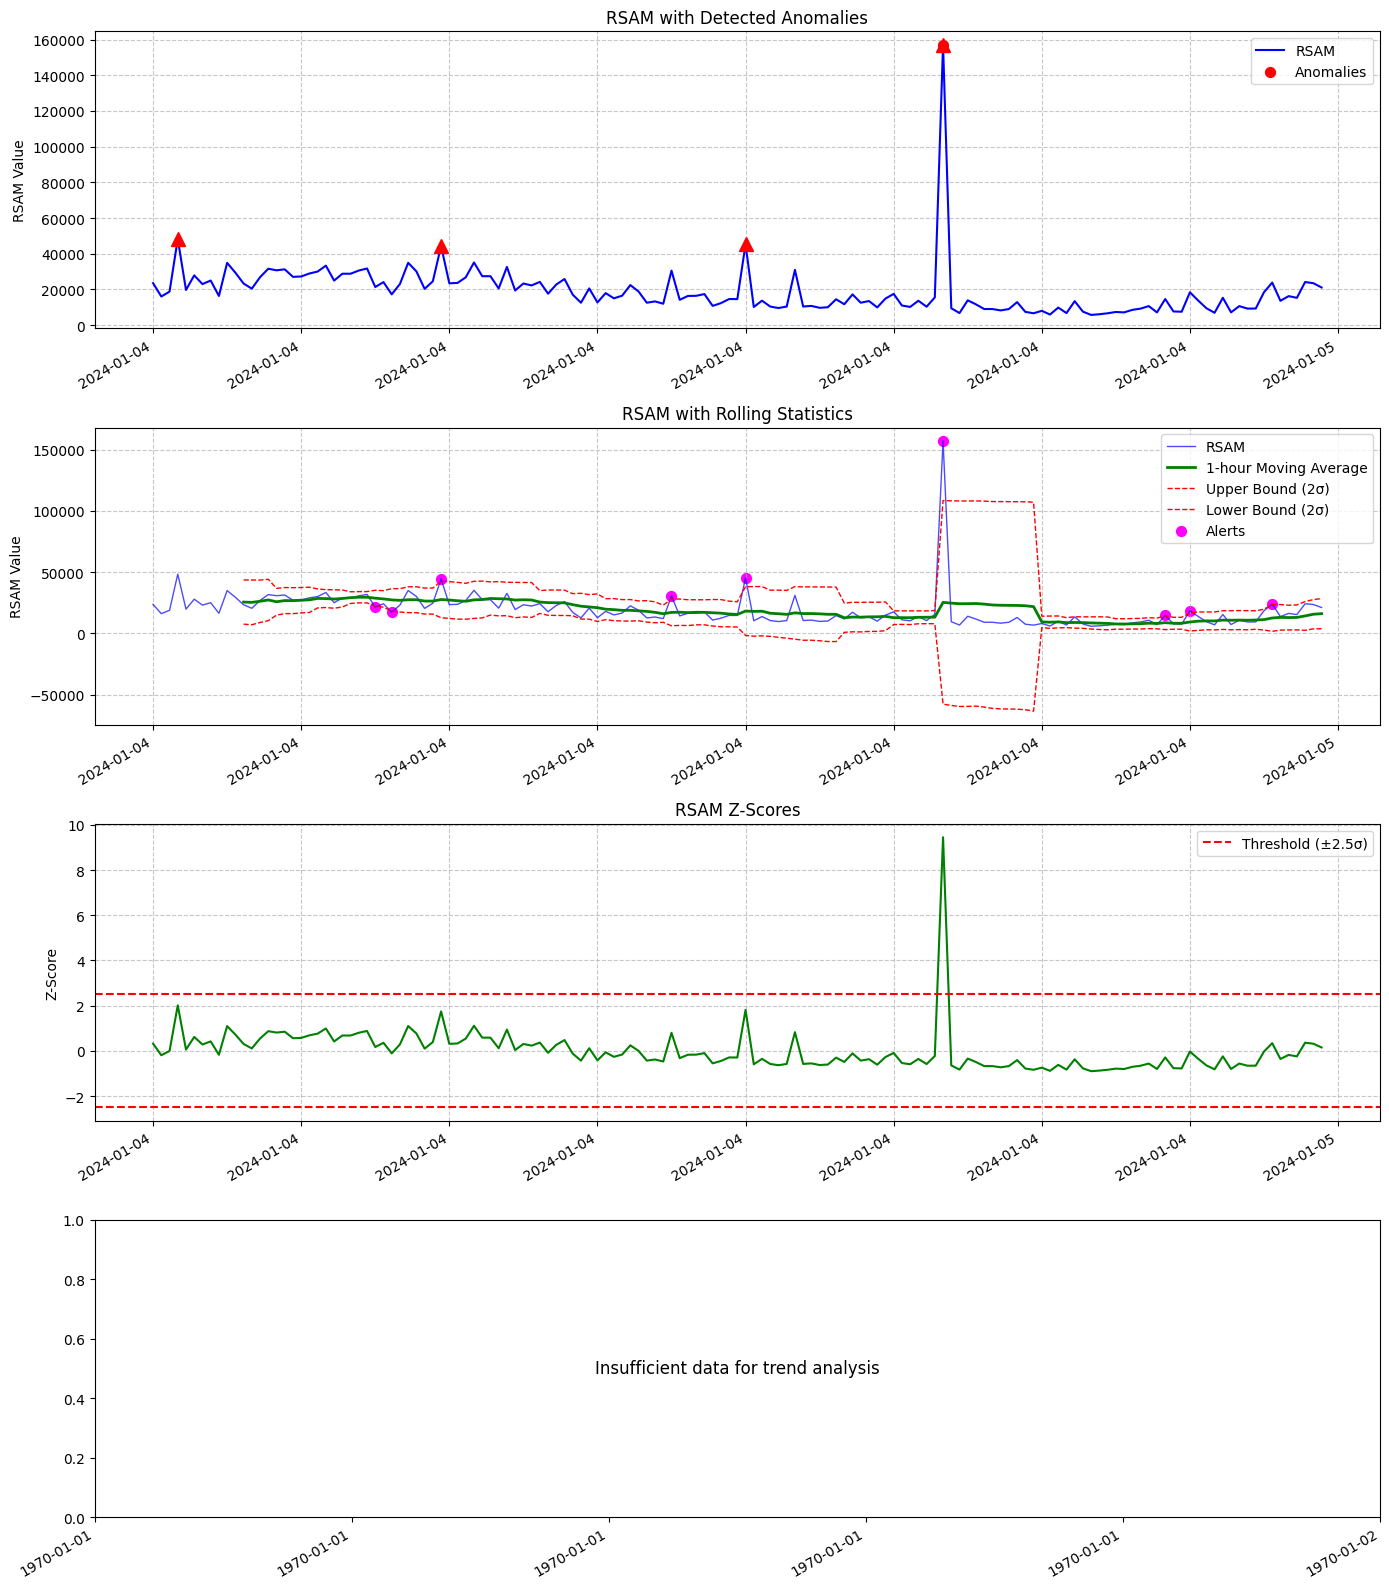


Hourly RSAM Statistics:
                  hour          rsam                              \
                                mean           std           min   
0  2024-01-04 00:00:00  25719.632420  11810.624166  16050.213397   
1  2024-01-04 01:00:00  25330.431038   6299.510257  16348.126904   
2  2024-01-04 02:00:00  27998.497480   4250.144603  20454.314641   
3  2024-01-04 03:00:00  28896.332571   2798.872649  24970.834627   
4  2024-01-04 04:00:00  25651.237019   5705.452901  17259.766252   
5  2024-01-04 05:00:00  29575.411767   8946.097165  20333.550716   
6  2024-01-04 06:00:00  27317.980694   4232.880860  23441.943862   
7  2024-01-04 07:00:00  23739.037512   4699.564095  19425.137128   
8  2024-01-04 08:00:00  19415.000000   4684.065318  12563.890554   
9  2024-01-04 09:00:00  17253.018303   3347.344600  12735.097255   
10 2024-01-04 10:00:00  16498.519398   7050.445663  12006.041010   
11 2024-01-04 11:00:00  14368.909970   2471.840378  10810.397471   
12 2024-01-04 12:00:00 

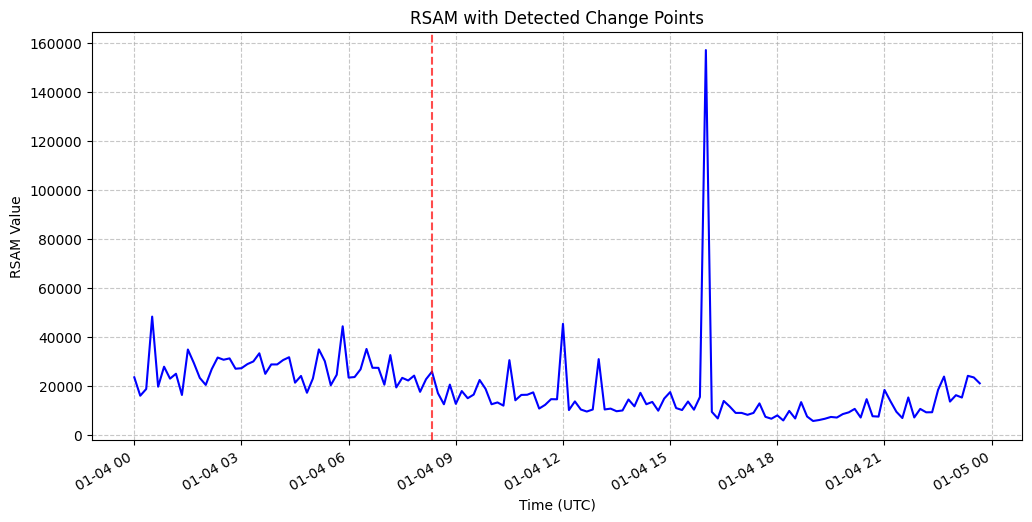

In [50]:
# ------------ VISUALIZATION ------------

# Create a multi-panel figure
fig = plt.figure(figsize=(14, 16))

# Plot 1: Raw RSAM values with anomalies highlighted
ax1 = plt.subplot(4, 1, 1)
ax1.plot(rsam_df['timestamp'], rsam_df['rsam'], 'b-', linewidth=1.5, label='RSAM')
if len(anomalies) > 0:
    ax1.scatter(anomalies['timestamp'], anomalies['rsam'], c='red', s=50, label='Anomalies')
for i in range(len(peak_times)):
    ax1.plot(peak_times[i], peak_values[i], 'r^', markersize=10)
ax1.set_title('RSAM with Detected Anomalies')
ax1.set_ylabel('RSAM Value')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend()

# Plot 2: RSAM with rolling statistics
ax2 = plt.subplot(4, 1, 2)
ax2.plot(rsam_df['timestamp'], rsam_df['rsam'], 'b-', linewidth=1, alpha=0.7, label='RSAM')
ax2.plot(rsam_df['timestamp'], rsam_df['rolling_mean'], 'g-', linewidth=2, label='1-hour Moving Average')
ax2.plot(rsam_df['timestamp'], rsam_df['upper_bound'], 'r--', linewidth=1, label='Upper Bound (2σ)')
ax2.plot(rsam_df['timestamp'], rsam_df['lower_bound'], 'r--', linewidth=1, label='Lower Bound (2σ)')
if len(alerts) > 0:
    ax2.scatter(alerts['timestamp'], alerts['rsam'], c='magenta', s=50, label='Alerts')
ax2.set_title('RSAM with Rolling Statistics')
ax2.set_ylabel('RSAM Value')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# Plot 3: Z-scores
ax3 = plt.subplot(4, 1, 3)
ax3.plot(rsam_df['timestamp'], rsam_df['z_score'], 'g-', linewidth=1.5)
ax3.axhline(y=2.5, color='r', linestyle='--', label='Threshold (±2.5σ)')
ax3.axhline(y=-2.5, color='r', linestyle='--')
ax3.set_title('RSAM Z-Scores')
ax3.set_ylabel('Z-Score')
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend()

# Plot 4: Time series decomposition (if available)
ax4 = plt.subplot(4, 1, 4)
if len(rsam_values) >= 24:
    try:
        trend.plot(ax=ax4, label='Trend', color='blue', linewidth=2)
        ax4.set_title('RSAM Trend Component')
        ax4.set_xlabel('Time (UTC)')
        ax4.set_ylabel('Trend')
        
        # Add trend line
        if 'trend_series' in locals():
            x_values = range(len(trend_series))
            ax4.plot([trend_series.index[0], trend_series.index[-1]], 
                     [intercept, intercept + slope * (len(trend_series)-1)], 
                     'r--', linewidth=1.5, label=f'Slope: {slope:.6f}')
        
        ax4.grid(True, linestyle='--', alpha=0.7)
        ax4.legend()
    except:
        ax4.text(0.5, 0.5, 'Insufficient data for trend analysis', 
                horizontalalignment='center', verticalalignment='center',
                transform=ax4.transAxes, fontsize=12)
else:
    ax4.text(0.5, 0.5, 'Insufficient data for trend analysis', 
            horizontalalignment='center', verticalalignment='center',
            transform=ax4.transAxes, fontsize=12)

# Format all x-axes to show dates nicely
for ax in [ax1, ax2, ax3, ax4]:
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('rsam_statistical_analysis.png', dpi=300)
plt.show()

# ------------ ADDITIONAL STATISTICS ------------

# 7. Hourly RSAM statistics
rsam_df['hour'] = rsam_df['timestamp'].dt.floor('h')
hourly_stats = rsam_df.groupby('hour').agg({
    'rsam': ['mean', 'std', 'min', 'max', 'count']
}).reset_index()

print("\nHourly RSAM Statistics:")
print(hourly_stats)

# 8. Calculate cumulative RSAM (useful for tracking total seismic energy release)
rsam_df['cumulative_rsam'] = rsam_df['rsam'].cumsum()

# 9. Detect change points in RSAM trend (optional, requires ruptures package)
try:
    import ruptures as rpt
    
    # Convert to numpy array for change point detection
    signal = np.array(rsam_values)
    
    # Detect change points
    algo = rpt.Pelt(model="l1", min_size=50, jump=5).fit(signal)
    change_pts = algo.predict(pen=30)  # Adjust penalty parameter as needed
    
    print(f"\nDetected {len(change_pts)-1} change points in RSAM trend")
    
    # Convert change points to timestamps
    change_timestamps = [timestamps[i] for i in change_pts[:-1]]  # Exclude last point which is the end
    
    # Plot change points
    plt.figure(figsize=(12, 6))
    plt.plot(timestamps, rsam_values, 'b-', linewidth=1.5)
    for cp in change_timestamps:
        plt.axvline(x=cp, color='r', linestyle='--', alpha=0.7)
    plt.title('RSAM with Detected Change Points')
    plt.xlabel('Time (UTC)')
    plt.ylabel('RSAM Value')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.gcf().autofmt_xdate()
    plt.savefig('rsam_change_points.png', dpi=300)
    
except ImportError:
    print("\nNote: For change point detection, install ruptures package with 'pip install ruptures'")

# 10. Generate summary report
summary = {
    'Start Time': timestamps[0],
    'End Time': timestamps[-1],
    'Duration (hours)': (timestamps[-1] - timestamps[0]).total_seconds() / 3600,
    'Mean RSAM': rsam_mean,
    'Median RSAM': rsam_median,
    'Standard Deviation': rsam_std,
    'Minimum RSAM': rsam_min,
    'Maximum RSAM': rsam_max,
    'Number of Anomalies': len(anomalies),
    'Number of Alerts': len(alerts),
    'Number of Peaks': len(peaks)
}

print("\nRSAM Analysis Summary:")
for key, value in summary.items():
    print(f"{key}: {value}")